# Component 1 Research Notebook: JKH

This notebook runs the full Component 1 research flow for **JKH** only.

Formula used throughout the project:

- `Deviation = abs(actual_price - predicted_price)`
- `volume_scaled = volume / 1_000_000`
- `liquidity_aware_anomaly_score = deviation / (volume_scaled + epsilon)`

The notebook keeps **final anomaly detection** separate from **structural value opportunity detection**:

- `liquidity_anomaly_flag`
- `prediction_band_anomaly_flag`
- `structural_value_signal`
- `final_anomaly_detected`

The 3-month output is presented as a **model-based scenario forecast**, not a guaranteed future price and not financial advice.


In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from component1_research import (
    ResearchConfig,
    build_data_audit,
    build_data_quality_summary,
    build_data_source_note,
    load_stock_history,
    run_research_pipeline,
    save_research_artifacts,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)


In [2]:
stock_code = "JKH"
raw_df = load_stock_history(stock_code)
audit_df = build_data_audit(raw_df)
quality_df = build_data_quality_summary(raw_df)
data_source_note = build_data_source_note(raw_df)

coverage_summary = pd.DataFrame(
    [
        {
            "stock": stock_code,
            "rows": len(raw_df),
            "start_date": raw_df["date"].min().date(),
            "end_date": raw_df["date"].max().date(),
            "data_source": quality_df.iloc[0]["data_source"],
        }
    ]
)

display(Markdown("## Data Availability Audit"))
display(coverage_summary)
display(audit_df)
display(Markdown("## Data Quality Summary"))
display(quality_df)
display(Markdown("## Data Source Note"))
print(data_source_note)
display(Markdown("## Raw Data Preview"))
display(raw_df.head(3))
display(raw_df.tail(3))


## Data Availability Audit

,stock,rows,start_date,end_date,data_source
0,JKH,3308,2012-02-22,2026-05-07,tradingview_cselk_fallback


,field,required_for,status,note
0,date,core_inputs,available_raw,temporal ordering
1,open,core_inputs,available_raw,market features
2,high,core_inputs,available_raw,market features
3,low,core_inputs,available_raw,market features
4,close,core_inputs,available_raw,market features and prediction target
5,volume,core_inputs,available_raw,liquidity-aware anomaly scoring
6,return_1d,feature_engineering,derived,derived from close prices
7,moving averages,feature_engineering,derived,derived from close prices
8,volatility,feature_engineering,derived,derived from rolling returns
9,momentum,feature_engineering,derived,derived from lagged closes


## Data Quality Summary

,stock,rows,start_date,end_date,missing_ohlcv_count,duplicate_date_count,zero_volume_count,data_source
0,JKH,3308,2012-02-22,2026-05-07,0,0,0,tradingview_cselk_fallback


## Data Source Note

The CSV source column indicates tradingview_cselk_fallback, so this is not a pure Ideabeam-only dataset. Historical OHLCV was recovered through the TradingView CSELK fallback path when the Ideabeam workflow was unavailable.


## Raw Data Preview

,date,symbol,open,high,low,close,volume,source,return_1d,log_return_1d,range_pct,volume_20d_ma,volume_ratio_20d,stock_code
0,2012-02-22,JKH.N0000,17.351429,17.361407,16.613070,17.351429,13343590,tradingview_cselk_fallback,NaN,NaN,0.043128,NaN,NaN,JKH
1,2012-02-23,JKH.N0000,17.351429,17.760520,17.261629,17.680697,4216350,tradingview_cselk_fallback,0.018976,0.018799,0.028217,NaN,NaN,JKH
2,2012-02-24,JKH.N0000,17.351429,17.660741,17.351429,17.570941,213490,tradingview_cselk_fallback,-0.006208,-0.006227,0.017604,NaN,NaN,JKH


,date,symbol,open,high,low,close,volume,source,return_1d,log_return_1d,range_pct,volume_20d_ma,volume_ratio_20d,stock_code
3305,2026-05-05,JKH.N0000,20.4,20.4,20.3,20.4,1911630,tradingview_cselk_fallback,0.000000,0.000000,0.004902,5588003.20,0.342095,JKH
3306,2026-05-06,JKH.N0000,20.4,20.7,20.4,20.6,6166755,tradingview_cselk_fallback,0.009804,0.009756,0.014563,5656391.45,1.090228,JKH
3307,2026-05-07,JKH.N0000,20.6,20.8,20.6,20.7,6268465,tradingview_cselk_fallback,0.004854,0.004843,0.009662,5307985.20,1.180950,JKH


In [3]:
config = ResearchConfig(
    stock_code=stock_code,
    epochs=12,
    lookback=20,
    batch_size=32,
)

results = run_research_pipeline(config)
artifact_paths = save_research_artifacts(results)
dashboard = results["dashboard_output"]

display(Markdown("## Pipeline Configuration"))
display(pd.DataFrame([results["config"]]))


## Pipeline Configuration

,stock_code,data_dir,artifact_dir,lookback,test_fraction,val_fraction,epochs,batch_size,hidden_size,num_layers,dropout,learning_rate,weight_decay,random_seed,anomaly_quantile,liquidity_epsilon,volume_scale,top_k_explanation,esi_top_k,esi_window,esi_step,isolation_forest_contamination,anomaly_search_min_quantile,anomaly_search_max_quantile,anomaly_search_grid_size,prediction_band_quantile,structural_gap_quantile,forecast_horizon_days,forecast_interval_z,recent_anomaly_window,surrogate_estimators,walk_forward_folds,low_volume_relative_threshold,thin_trading_relative_threshold,direction_neutral_scale,direction_probability_floor,selective_direction_threshold_candidates,selective_direction_min_coverage,forecast_weight_epsilon,target_price,shock_pressure_quantile,shock_max_penalty_pct,shock_penalty_strength,shock_reliability_min_score,max_rows,verbose
0,JKH,data,artifacts/component1,20,0.2,0.1,12,32,32,2,0.15,0.001,0.00001,42,0.95,0.000001,1000000.0,3,3,60,20,0.05,0.6,0.995,60,0.95,0.9,60,1.96,60,300,3,0.5,0.25,0.1,0.000001,"(0.55, 0.6, 0.65, 0.7)",0.25,0.000001,None,0.9,0.15,0.1,5.0,None,False


In [4]:
display(Markdown("## Latest Dashboard Summary"))

summary_df = pd.DataFrame(
    [
        {
            "selected_stock": dashboard["selected_stock"],
            "analysis_date": dashboard["analysis_date"],
            "predicted_price": dashboard["predicted_price"],
            "actual_price": dashboard["actual_price"],
            "deviation": dashboard["deviation"],
            "volume_scaled": dashboard["volume_scaled"],
            "market_confirmed_score": dashboard["market_confirmed_score"],
            "liquidity_aware_anomaly_score": dashboard["liquidity_aware_anomaly_score"],
            "anomaly_threshold": dashboard["anomaly_threshold"],
            "final_anomaly_detected": dashboard["final_anomaly_detected"],
            "liquidity_anomaly_flag": dashboard["liquidity_anomaly_flag"],
            "prediction_band_anomaly_flag": dashboard["prediction_band_anomaly_flag"],
            "structural_value_signal": dashboard["structural_value_signal"],
            "value_opportunity_flag": dashboard["value_opportunity_flag"],
            "risk_level": dashboard["risk_level"],
        }
    ]
)

price_level_df = pd.DataFrame([dashboard["prediction_metrics"]])
naive_df = pd.DataFrame([dashboard["naive_baseline_metrics"]])
price_direction_df = pd.DataFrame([dashboard["price_regression_directional_metrics"]])
directional_df = pd.DataFrame(
    [
        {
            "best_model": dashboard["best_direction_model"]["model"],
            "task": dashboard["directional_metrics"]["task"],
            "directional_accuracy": dashboard["directional_metrics"]["directional_accuracy"],
            "balanced_accuracy": dashboard["directional_metrics"]["balanced_accuracy"],
            "macro_f1": dashboard["directional_metrics"]["macro_f1"],
            "down_precision": dashboard["directional_metrics"]["down_precision"],
            "down_recall": dashboard["directional_metrics"]["down_recall"],
            "neutral_precision": dashboard["directional_metrics"]["neutral_precision"],
            "neutral_recall": dashboard["directional_metrics"]["neutral_recall"],
            "up_precision": dashboard["directional_metrics"]["up_precision"],
            "up_recall": dashboard["directional_metrics"]["up_recall"],
            "support_down": dashboard["directional_metrics"]["support_down"],
            "support_neutral": dashboard["directional_metrics"]["support_neutral"],
            "support_up": dashboard["directional_metrics"]["support_up"],
        }
    ]
)
direction_confusion_df = pd.DataFrame(
    dashboard["direction_confusion_matrix"]["matrix"],
    index=dashboard["direction_confusion_matrix"]["labels"],
    columns=dashboard["direction_confusion_matrix"]["labels"],
)
direction_model_comparison_df = pd.DataFrame(dashboard["direction_model_comparison"]["three_class"])
binary_direction_model_comparison_df = pd.DataFrame(dashboard["direction_model_comparison"]["binary"])
selective_direction_validation_df = pd.DataFrame(dashboard["selective_direction_metrics"]["validation_threshold_table"])
selective_direction_test_df = pd.DataFrame(dashboard["selective_direction_metrics"]["test_threshold_table"])
thin_trading_df = pd.DataFrame([dashboard["thin_trading_diagnostics"]])
threshold_df = pd.DataFrame([dashboard["threshold_calibration"]])
forecast_reliability_df = pd.DataFrame([dashboard["forecast_reliability_metrics"]])
shock_adjusted_df = pd.DataFrame(
    [
        {
            "current_price": dashboard["current_price"],
            "structural_forecast_3m": dashboard["structural_forecast_3m"],
            "anomaly_adjusted_forecast_3m": dashboard["anomaly_adjusted_forecast_3m"],
            "recovery_gap": dashboard["recovery_gap"],
            "recovery_gap_pct": dashboard["recovery_gap_pct"],
            "target_price": dashboard["target_price"],
            "target_breakout_probability": dashboard["target_breakout_probability"],
            "anomaly_adjusted_breakout_probability": dashboard["anomaly_adjusted_breakout_probability"],
            "anomaly_pressure_score": dashboard["anomaly_pressure_score"],
            "anomaly_pressure_threshold": dashboard["anomaly_pressure_threshold"],
            "temporary_anomaly_drag_flag": dashboard["temporary_anomaly_drag_flag"],
            "anomaly_penalty_pct": dashboard["anomaly_penalty_pct"],
            "anomaly_type": dashboard["anomaly_type"],
        }
    ]
)
counterfactual_df = pd.DataFrame(
    [
        {
            "current_price": dashboard["current_price"],
            "current_regime_forecast_3m": dashboard["current_regime_forecast_3m"],
            "counterfactual_structural_forecast_3m": dashboard["counterfactual_structural_forecast_3m"],
            "structural_suppression_gap": dashboard["structural_suppression_gap"],
            "structural_suppression_gap_pct": dashboard["structural_suppression_gap_pct"],
            "pre_shock_anchor_price": dashboard["pre_shock_anchor_price"],
            "pre_shock_anchor_date": dashboard["pre_shock_anchor_date"],
            "regime_shift_score": dashboard["regime_shift_score"],
            "regime_shift_threshold": dashboard["regime_shift_threshold"],
            "regime_shift_flag": dashboard["regime_shift_flag"],
            "suppression_materiality_threshold_pct": dashboard["suppression_materiality_threshold_pct"],
            "suppressed_but_not_currently_anomalous_flag": dashboard["suppressed_but_not_currently_anomalous_flag"],
        }
    ]
)
walk_forward_aggregate_df = pd.DataFrame(dashboard["walk_forward_validation"]["aggregate_metrics"])
walk_forward_fold_df = pd.DataFrame(dashboard["walk_forward_validation"]["fold_metrics"])

display(summary_df)
display(Markdown("## Price-Level Prediction Quality"))
display(price_level_df)
display(Markdown("## Naive Baseline Comparison"))
display(naive_df)
display(pd.DataFrame([dashboard["lstm_vs_naive_comparison"]]))
display(Markdown("## Price Regression Direction Check"))
display(price_direction_df)
display(Markdown("## Directional Prediction Quality"))
display(pd.DataFrame([dashboard["best_direction_model"]]))
display(directional_df)
display(direction_confusion_df)
display(Markdown("## Direction Model Comparison"))
display(direction_model_comparison_df)
display(binary_direction_model_comparison_df)
display(Markdown("## Selective High-Confidence Direction Signals"))
display(selective_direction_validation_df)
display(selective_direction_test_df)
display(pd.DataFrame([{
    "next_day_direction_prediction": dashboard["next_day_direction_prediction"],
    "next_day_direction_confidence": dashboard["next_day_direction_confidence"],
    "selective_direction_signal": dashboard["selective_direction_signal"],
    "selective_direction_confidence": dashboard["selective_direction_confidence"],
    "selective_direction_threshold": dashboard["selective_direction_threshold"],
    "signal_coverage_rate": dashboard["signal_coverage_rate"],
    "no_signal_rate": dashboard["no_signal_rate"],
}]))
print(dashboard["direction_prediction_note"])
print(dashboard["selective_direction_metrics"]["note"])
display(Markdown("## Proxy Anomaly Label Construction"))
print(dashboard["proxy_anomaly_label_construction"])
display(Markdown("## Anomaly Detection Quality (Test Split)"))
display(results["anomaly_comparison"])
display(Markdown("## Anomaly Method Metrics By Split"))
display(results["anomaly_method_split_metrics"])
display(Markdown("## Anomaly Confusion Matrices"))
display(results["anomaly_confusion_matrices"])
display(Markdown("## Threshold Calibration"))
display(threshold_df)
display(pd.DataFrame([results["anomaly_threshold_selection"]["validation_metrics"]]))
display(results["anomaly_threshold_selection"]["search_table"].head(10))
display(Markdown("## Prediction Band And Structural Calibration"))
display(pd.DataFrame([results["prediction_band_selection"]]))
display(Markdown("## Thin-Trading Diagnostics"))
display(thin_trading_df)
display(Markdown("## Forecast Reliability"))
display(forecast_reliability_df)
display(pd.DataFrame(results["forecast_component_backtest"]))
print(dashboard["forecast_reliability_note"])
display(Markdown("# Shock-Adjusted Anomaly Interpretation"))
display(shock_adjusted_df)
print(dashboard["shock_adjusted_explanation"])
print(dashboard["external_data_limitations"])
display(Markdown("# Counterfactual Structural Suppression Layer"))
display(counterfactual_df)
print(dashboard["structural_suppression_interpretation"])
print("Regime threshold basis:", dashboard["regime_shift_threshold_basis"])
print("Counterfactual limitations:", " ".join(dashboard["counterfactual_layer_limitations"]))
display(Markdown("## Lightweight Walk-Forward Validation"))
print(dashboard["walk_forward_validation"]["method_note"])
display(walk_forward_aggregate_df)
display(walk_forward_fold_df)
display(Markdown("## Recent Anomaly Summary"))
display(pd.DataFrame([dashboard["recent_anomaly_summary"]]))
display(Markdown("## Dashboard JSON"))
print(json.dumps(dashboard, indent=2))


## Latest Dashboard Summary

,selected_stock,analysis_date,predicted_price,actual_price,deviation,volume_scaled,market_confirmed_score,liquidity_aware_anomaly_score,anomaly_threshold,final_anomaly_detected,liquidity_anomaly_flag,prediction_band_anomaly_flag,structural_value_signal,value_opportunity_flag,risk_level
0,JKH,2026-05-07,20.5949,20.7,0.1051,6.268465,0.208438,0.016764,0.961452,False,False,False,False,False,Low


## Price-Level Prediction Quality

,mae,rmse,mape,mape_pct,approximate_price_level_accuracy_pct,residual_mean,residual_std,residual_min,residual_max,latest_prediction_error,directional_accuracy
0,0.326799,0.445485,0.01586,1.585963,98.414037,-0.009346,0.445387,-1.899378,1.828009,0.105083,0.531685


## Naive Baseline Comparison

...

,fold,train_period_start,train_period_end,validation_period_start,validation_period_end,rows,mae,rmse,mape,mape_pct,directional_accuracy,balanced_directional_accuracy,interval_95_coverage
0,1,2012-06-14,2023-08-15,2023-08-16,2024-07-10,216,0.142773,0.202630,0.007398,0.739797,0.444444,0.342671,0.990741
1,2,2012-06-14,2024-07-10,2024-07-11,2025-06-17,216,0.222772,0.316131,0.010993,1.099347,0.481481,0.402043,0.949074
2,3,2012-06-14,2025-06-17,2025-06-18,2026-05-07,215,0.251347,0.340493,0.011559,1.155916,0.443925,0.382023,0.939535


## Recent Anomaly Summary

,recent_window_start,recent_window_end,recent_window_rows,recent_anomaly_count,recent_liquidity_anomaly_count,recent_prediction_band_anomaly_count,recent_downside_count,recent_structural_discount_count,latest_recent_anomaly,latest_recent_downside_anomaly,latest_recent_structural_anomaly
0,2026-02-05,2026-05-07,60,10,0,10,4,15,"{'date': '2026-04-20', 'predicted_price': 19.4...","{'date': '2026-03-19', 'predicted_price': 19.0...","{'date': '2026-04-02', 'predicted_price': 18.2..."


## Dashboard JSON

{
  "selected_stock": "JKH",
  "analysis_date": "2026-05-07",
  "formula": "Deviation = abs(actual_price - predicted_price); volume_scaled = volume / 1_000_000; liquidity_aware_anomaly_score = deviation / (volume_scaled + epsilon)",
  "predicted_price": 20.5949,
  "actual_price": 20.7,
  "signed_residual": 0.1051,
  "deviation": 0.1051,
  "volume": 6268465,
  "volume_scaled": 6.268465,
  "epsilon": 1e-06,
  "anomaly_threshold": 0.961452,
  "prediction_band_threshold": 1.05,
  "structural_gap_threshold_pct": 4.8902,
  "threshold_basis": "Validation-only calibration on the chronological validation split using a train/validation quantile grid. Thresholds are selected before the test split is evaluated.",
  "anomaly_threshold_basis": "Validation-calibrated final anomaly logic. liquidity_anomaly_flag uses the liquidity-aware anomaly score threshold below; final_anomaly_detected = liquidity_anomaly_flag OR prediction_band_anomaly_flag. structural_value_signal is reported separately and is no

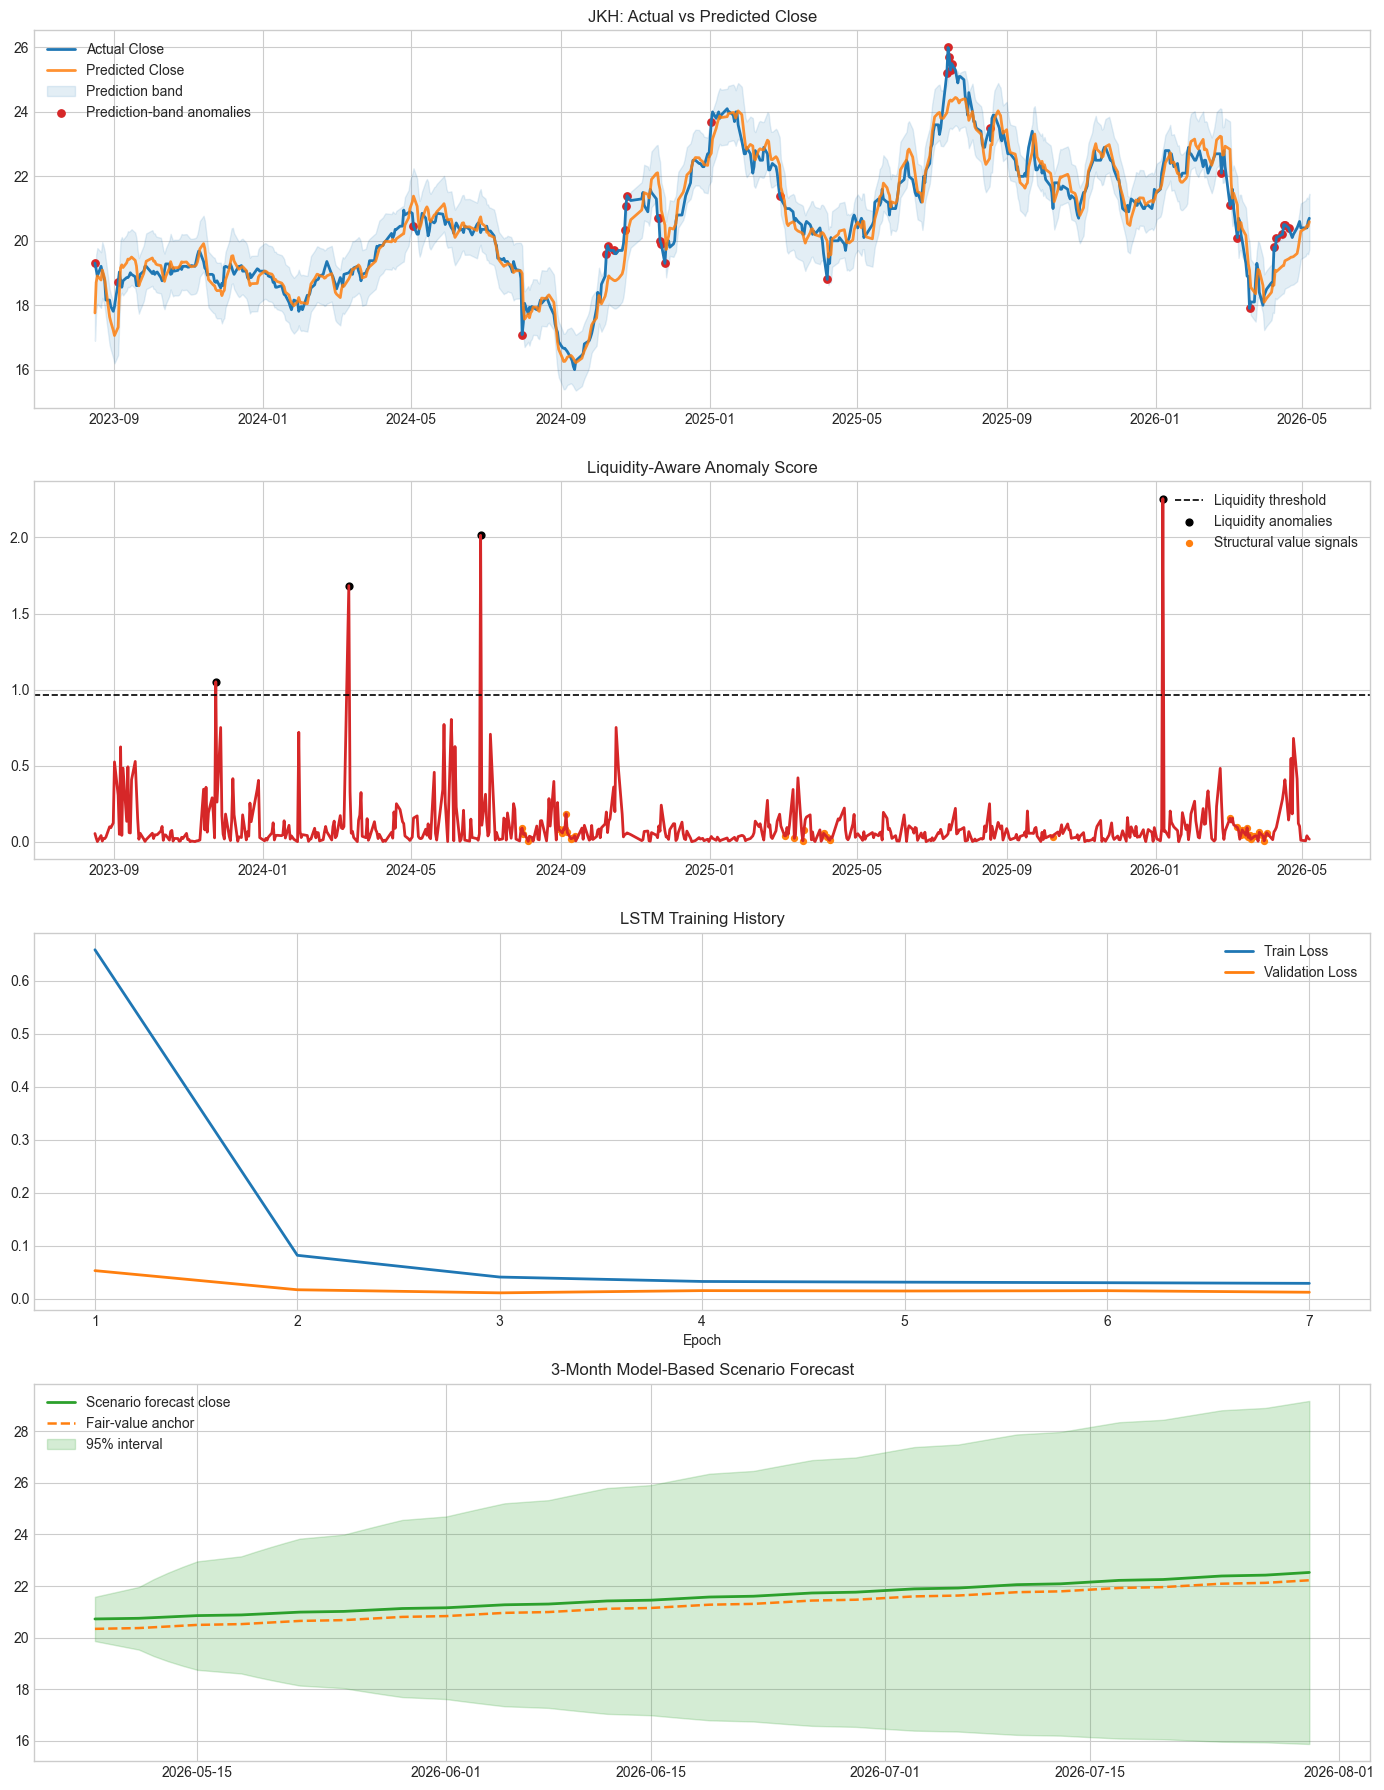

In [5]:
test_df = results["test_results"].copy()
test_df["date"] = pd.to_datetime(test_df["date"])
forecast_df = results["forecast_3m"].copy()
forecast_df["date"] = pd.to_datetime(forecast_df["date"])
history_df = pd.DataFrame(results["training_history"])

fig, axes = plt.subplots(4, 1, figsize=(14, 18))

axes[0].plot(test_df["date"], test_df["actual_price"], label="Actual Close", linewidth=2)
axes[0].plot(test_df["date"], test_df["predicted_price"], label="Predicted Close", linewidth=2, alpha=0.85)
axes[0].fill_between(
    test_df["date"],
    test_df["prediction_band_lower"],
    test_df["prediction_band_upper"],
    color="tab:blue",
    alpha=0.12,
    label="Prediction band",
)
axes[0].scatter(
    test_df.loc[test_df["prediction_band_anomaly_flag"], "date"],
    test_df.loc[test_df["prediction_band_anomaly_flag"], "actual_price"],
    color="tab:red",
    s=28,
    label="Prediction-band anomalies",
)
axes[0].set_title(f"{stock_code}: Actual vs Predicted Close")
axes[0].legend()

axes[1].plot(test_df["date"], test_df["liquidity_aware_anomaly_score"], color="tab:red", linewidth=2)
axes[1].axhline(
    dashboard["anomaly_threshold"],
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Liquidity threshold",
)
axes[1].scatter(
    test_df.loc[test_df["liquidity_anomaly_flag"], "date"],
    test_df.loc[test_df["liquidity_anomaly_flag"], "liquidity_aware_anomaly_score"],
    color="black",
    s=24,
    label="Liquidity anomalies",
)
axes[1].scatter(
    test_df.loc[test_df["structural_value_signal"], "date"],
    test_df.loc[test_df["structural_value_signal"], "liquidity_aware_anomaly_score"],
    color="tab:orange",
    s=18,
    label="Structural value signals",
)
axes[1].set_title("Liquidity-Aware Anomaly Score")
axes[1].legend()

axes[2].plot(history_df.index + 1, history_df["train_loss"], label="Train Loss", linewidth=2)
axes[2].plot(history_df.index + 1, history_df["val_loss"], label="Validation Loss", linewidth=2)
axes[2].set_title("LSTM Training History")
axes[2].set_xlabel("Epoch")
axes[2].legend()

axes[3].plot(forecast_df["date"], forecast_df["predicted_close"], color="tab:green", linewidth=2, label="Scenario forecast close")
axes[3].plot(forecast_df["date"], forecast_df["fair_value_anchor"], color="tab:orange", linewidth=1.8, linestyle="--", label="Fair-value anchor")
axes[3].fill_between(
    forecast_df["date"],
    forecast_df["lower_95"],
    forecast_df["upper_95"],
    color="tab:green",
    alpha=0.2,
    label="95% interval",
)
axes[3].set_title("3-Month Model-Based Scenario Forecast")
axes[3].legend()

plt.tight_layout()
plt.show()


In [6]:
display(Markdown("## Recent Downside, Value, And Final-Anomaly Rows"))

recent_window = results["config"]["recent_anomaly_window"]
recent_df = test_df.sort_values("date").tail(recent_window)

recent_downside = recent_df[
    recent_df["prediction_band_anomaly_flag"] & recent_df["downside_band_signal"]
][[
    "date",
    "predicted_price",
    "actual_price",
    "signed_residual",
    "deviation",
    "liquidity_aware_anomaly_score",
    "risk_level",
    "anomaly_side",
]]
recent_structural = recent_df[recent_df["structural_value_signal"]][[
    "date",
    "predicted_price",
    "actual_price",
    "structural_expected_price",
    "structural_discount_pct",
    "risk_level",
]]
recent_final = recent_df[recent_df["final_anomaly_detected"]][[
    "date",
    "predicted_price",
    "actual_price",
    "signed_residual",
    "deviation",
    "liquidity_aware_anomaly_score",
    "risk_level",
    "anomaly_side",
]]

display(recent_downside.tail(12))
display(recent_structural.tail(12))
display(recent_final.tail(12))


## Recent Downside, Value, And Final-Anomaly Rows

,date,predicted_price,actual_price,signed_residual,deviation,liquidity_aware_anomaly_score,risk_level,anomaly_side
600,2026-02-24,23.225451,22.1,-1.125450,1.125450,0.268684,Medium,downside_band
604,2026-03-03,22.839117,21.1,-1.739117,1.739117,0.153971,High,downside_band
608,2026-03-09,21.116306,20.1,-1.016306,1.016306,0.093948,Medium,downside_band
616,2026-03-19,19.084642,17.9,-1.184643,1.184643,0.045244,Medium,downside_band


,date,predicted_price,actual_price,structural_expected_price,structural_discount_pct,risk_level
612,2026-03-13,20.378971,20.000000,21.412400,0.065962,Low
613,2026-03-16,20.168140,19.299999,21.257690,0.092093,Medium
614,2026-03-17,19.716621,18.900000,21.045179,0.101932,Low
615,2026-03-18,19.280758,18.900000,20.844540,0.093288,Low
616,2026-03-19,19.084642,17.900000,20.625769,0.132154,Medium
617,2026-03-20,18.557783,18.100000,20.378959,0.111829,Low
618,2026-03-23,18.401737,18.100000,20.197123,0.103833,Low
619,2026-03-24,18.355150,18.799999,20.082137,0.063845,Low
622,2026-03-27,19.071007,18.400000,19.910098,0.075846,Low
623,2026-03-30,18.617338,18.000000,19.700383,0.086312,Low


,date,predicted_price,actual_price,signed_residual,deviation,liquidity_aware_anomaly_score,risk_level,anomaly_side
600,2026-02-24,23.225451,22.100000,-1.125450,1.125450,0.268684,Medium,downside_band
604,2026-03-03,22.839117,21.100000,-1.739117,1.739117,0.153971,High,downside_band
608,2026-03-09,21.116306,20.100000,-1.016306,1.016306,0.093948,Medium,downside_band
616,2026-03-19,19.084642,17.900000,-1.184643,1.184643,0.045244,Medium,downside_band
628,2026-04-08,18.620348,19.799999,1.179651,1.179651,0.063985,Medium,upside_band
630,2026-04-10,19.045149,20.100000,1.054852,1.054852,0.094213,Medium,upside_band
631,2026-04-15,19.217762,20.200001,0.982239,0.982239,0.279441,Medium,upside_band
632,2026-04-16,19.230131,20.500000,1.269869,1.269869,0.337141,Medium,upside_band
633,2026-04-17,19.378199,20.500000,1.121801,1.121801,0.407476,Medium,upside_band
634,2026-04-20,19.437931,20.400000,0.962069,0.962069,0.142644,Medium,upside_band


In [7]:
display(Markdown("## Explainability And Stability"))

top_factors_df = pd.DataFrame(results["dashboard_output"]["top_shap_factors"])
rolling_features_df = pd.DataFrame(
    {
        "window_index": list(range(1, len(results["explanation"]["rolling_top_features"]) + 1)),
        "top_features": [", ".join(features) for features in results["explanation"]["rolling_top_features"]],
    }
)

display(top_factors_df)
display(rolling_features_df)

print("Explainability backend:", results["explanation"]["method"])
print("SHAP backend:", dashboard["shap_backend"])
print("SHAP explanation target:", results["explanation"]["shap_explanation_target"])
print(results["explanation"]["shap_explanation_note"])
print("Top feature contribution percentage:", dashboard["top_feature_contribution_percentage"])
print("Latest ESI:", dashboard["esi_latest"])
print("Mean ESI:", dashboard["esi_mean"])
print("Min ESI:", dashboard["esi_min"])
print("Max ESI:", dashboard["esi_max"])
print("Number of windows used:", dashboard["number_of_windows_used"])
print("ESI interpretation:", dashboard["esi_interpretation"])
print("Explanation stability comment:", dashboard["explanation_stability_comment"])
print("Dominance warning:", dashboard["dominance_warning"])
print("Narrative explanation:", dashboard["simple_explanation"])


## Explainability And Stability

,feature,contribution
0,Trading Volume,0.897866
1,1D Return,0.035935
2,RSI 14D,0.024461


,window_index,top_features
0,1,"volume_ratio_20d, moving_average_gap, atr_14"
1,2,"volume_ratio_20d, rsi_14, return_1d"
2,3,"volume_ratio_20d, rsi_14, return_1d"
3,4,"volume_ratio_20d, rsi_14, return_1d"
4,5,"volume_ratio_20d, return_1d, rsi_14"
5,6,"volume_ratio_20d, return_1d, rsi_14"
6,7,"volume_ratio_20d, return_1d, rsi_14"
7,8,"volume_ratio_20d, return_1d, rsi_14"
8,9,"volume_ratio_20d, return_1d, rsi_14"
9,10,"volume_ratio_20d, return_1d, rsi_14"


Explainability backend: tree_shap
SHAP backend: tree_shap
SHAP explanation target: surrogate_liquidity_anomaly_score
SHAP explains the surrogate anomaly-score model, not the LSTM internals directly.
Top feature contribution percentage: 89.786648
Latest ESI: 1.0
Mean ESI: 0.896552
Min ESI: 0.333333
Max ESI: 1.0
Number of windows used: 30
ESI interpretation: highly stable
Explanation stability comment: High
Dominance warning: Explanation is stable, but dominated by trading volume, so interpretation should be treated as volume-led.
Narrative explanation: The latest movement is within the model's normal range. The score behaviour was mainly influenced by lower trading volume, weaker recent returns, and stronger relative strength.


In [8]:
display(Markdown("## 3-Month Model-Based Scenario Forecast"))
display(forecast_df.head(10))
display(forecast_df.tail(10))


## 3-Month Model-Based Scenario Forecast

,date,scenario_lstm_close,naive_random_walk_close,moving_average_drift_close,ensemble_predicted_close,predicted_close,fair_value_anchor,lower_80,upper_80,lower_95,upper_95,forecast_step
0,2026-05-08,20.709955,20.700001,20.762194,20.725298,20.725298,20.341795,20.486326,20.964270,19.867178,21.583418,1
1,2026-05-11,20.720536,20.700001,20.824574,20.750823,20.750823,20.372331,20.412866,21.088780,19.537258,21.964388,2
2,2026-05-12,20.731728,20.700001,20.887142,20.776572,20.776572,20.402912,20.362661,21.190484,19.290265,22.262880,3
3,2026-05-13,20.743514,20.700001,20.949897,20.802541,20.802541,20.433539,20.324598,21.280485,19.086301,22.518781,4
4,2026-05-14,20.755878,20.700001,21.012841,20.828726,20.828726,20.464213,20.294369,21.363083,18.909912,22.747541,5
5,2026-05-15,20.768806,20.700001,21.075974,20.855124,20.855124,20.494932,20.269765,21.440483,18.753168,22.957080,6
6,2026-05-18,20.782281,20.700001,21.139297,20.881730,20.881730,20.525697,20.249470,21.513990,18.611358,23.152102,7
7,2026-05-19,20.796290,20.700001,21.202810,20.908542,20.908542,20.556509,20.232627,21.584456,18.481412,23.335672,8
8,2026-05-20,20.810819,20.700001,21.266514,20.935555,20.935555,20.587367,20.218640,21.652470,18.361195,23.509915,9
9,2026-05-21,20.825853,20.700001,21.330410,20.962767,20.962767,20.618271,20.207072,21.718462,18.249153,23.676381,10


,date,scenario_lstm_close,naive_random_walk_close,moving_average_drift_close,ensemble_predicted_close,predicted_close,fair_value_anchor,lower_80,upper_80,lower_95,upper_95,forecast_step
50,2026-07-17,21.752596,20.700001,24.122228,22.220375,22.220375,21.926098,20.513775,23.926975,16.092172,28.348578,51
51,2026-07-20,21.780541,20.700001,24.194703,22.254011,22.254011,21.959012,20.530761,23.977261,16.066019,28.442002,52
52,2026-07-21,21.808665,20.700001,24.267396,22.287771,22.287771,21.991975,20.548031,24.027512,16.040563,28.534979,53
53,2026-07-22,21.836963,20.700001,24.340308,22.321656,22.321656,22.024988,20.565580,24.077733,16.015788,28.627525,54
54,2026-07-23,21.865433,20.700001,24.413438,22.355665,22.355665,22.058050,20.583403,24.127928,15.991677,28.719654,55
55,2026-07-24,21.894070,20.700001,24.486789,22.389797,22.389797,22.091162,20.601496,24.178098,15.968215,28.811380,56
56,2026-07-27,21.922872,20.700001,24.560359,22.424052,22.424052,22.124324,20.619854,24.228249,15.945388,28.902716,57
57,2026-07-28,21.951834,20.700001,24.634151,22.458428,22.458428,22.157535,20.638473,24.278383,15.923181,28.993676,58
58,2026-07-29,21.980955,20.700001,24.708165,22.492926,22.492926,22.190797,20.657349,24.328503,15.901581,29.084271,59
59,2026-07-30,22.010231,20.700001,24.782400,22.527544,22.527544,22.224108,20.676477,24.378612,15.880575,29.174513,60


In [9]:
best_method = dashboard["best_anomaly_method"]
recent_summary = dashboard["recent_anomaly_summary"]
top_factor_text = ", ".join(
    f"{factor['feature']} ({factor['contribution']:.1%})"
    for factor in dashboard["top_shap_factors"]
)

latest_downside = recent_summary["latest_recent_downside_anomaly"]
if latest_downside:
    downside_sentence = (
        f"In the most recent {recent_summary['recent_window_rows']} test rows, the latest downside anomaly happened on "
        f"**{latest_downside['date']}**, when the model expected **{latest_downside['predicted_price']:.4f}** but the market closed at "
        f"**{latest_downside['actual_price']:.4f}**."
    )
else:
    downside_sentence = (
        f"In the most recent {recent_summary['recent_window_rows']} test rows, there was no downside prediction-band anomaly."
    )

latest_structural = recent_summary["latest_recent_structural_anomaly"]
if latest_structural:
    structural_sentence = (
        f"The latest structural value signal in the recent window appeared on **{latest_structural['date']}**, indicating a price below the slower fair-value anchor built from past-price structure."
    )
else:
    structural_sentence = "There is no structural value signal in the recent window."

value_sentence = (
    f"The latest row still carries a structural discount of **{dashboard['structural_discount']:.4f}** "
    f"({dashboard['structural_discount_pct']:.2f}% of structural expected price), so it is flagged as a value opportunity."
    if dashboard["value_opportunity_flag"]
    else f"The latest row does not qualify as a value-opportunity signal because the structural discount is only **{dashboard['structural_discount']:.4f}** "
         f"({dashboard['structural_discount_pct']:.2f}% of structural expected price)."
)
support_warning_text = ""
if not (best_method["tie"] and best_method["support_positive"] <= 2):
    support_warning_text = dashboard["support_warning"]
selective_test_metrics = dashboard["selective_direction_metrics"]["selected_test_metrics"]
selective_signal_accuracy = selective_test_metrics["signal_accuracy"]
selective_signal_macro_f1 = selective_test_metrics["signal_macro_f1"]
selective_signal_coverage_pct = (
    dashboard["signal_coverage_rate"] * 100 if dashboard["signal_coverage_rate"] is not None else float("nan")
)

interpretation = f"""
## Interpretation for {stock_code}

The dataset contains **{int(quality_df.iloc[0]['rows']):,}** trading observations for **{stock_code}** from **{quality_df.iloc[0]['start_date']}** to **{quality_df.iloc[0]['end_date']}**. The CSV source note is: {dashboard['data_source_note']}

The latest row uses the formula **{dashboard['formula']}**. For the latest observation, the model predicts **{dashboard['predicted_price']:.4f}** against an actual close of **{dashboard['actual_price']:.4f}**, so deviation is **{dashboard['deviation']:.4f}**, volume_scaled is **{dashboard['volume_scaled']:.6f}**, epsilon is **{dashboard['epsilon']:.8f}**, and the liquidity-aware anomaly score is **{dashboard['liquidity_aware_anomaly_score']:.6f}**.

For price-level prediction quality, the notebook reports MAE **{dashboard['prediction_metrics']['mae']:.4f}**, RMSE **{dashboard['prediction_metrics']['rmse']:.4f}**, MAPE **{dashboard['prediction_metrics']['mape_pct']:.3f}%**, and approximate price-level accuracy **{dashboard['prediction_metrics']['approximate_price_level_accuracy_pct']:.3f}%**. Low MAPE supports using the LSTM as an expected-price baseline, but the price-regression directional check is only **{dashboard['price_regression_directional_metrics']['directional_accuracy'] * 100:.2f}%**, so the regression model alone should not be claimed as a strong up/down predictor.

Against the naive previous-close baseline, the LSTM {'beats' if dashboard['lstm_vs_naive_comparison']['beats_naive_on_mape'] else 'does not beat'} the naive model on MAPE and {'beats' if dashboard['lstm_vs_naive_comparison']['beats_naive_on_directional_accuracy'] else 'does not beat'} it on directional accuracy. This comparison is important because a stock model must be evaluated against a simple persistence rule before stronger claims are made.

Directional prediction was improved by adding a dedicated classification layer instead of relying only on next-price regression. The best 3-class direction model here is **{dashboard['best_direction_model']['model']}**, with test directional accuracy **{dashboard['directional_metrics']['directional_accuracy'] * 100:.2f}%**, balanced accuracy **{dashboard['directional_metrics']['balanced_accuracy'] * 100:.2f}%**, and macro F1 **{dashboard['directional_metrics']['macro_f1']:.4f}**. The neutral threshold basis is **{dashboard['directional_metrics']['neutral_threshold_basis']}**, which helps avoid forcing very small noisy price changes into pure up/down labels.

For binary direction, the best model is **{dashboard['directional_metrics']['binary_direction_comparison']['best_model']['model']}**. A selective high-confidence signal layer is then calibrated on validation data only. The selected threshold is **{dashboard['selective_direction_threshold']:.2f}**, producing test signal accuracy **{selective_signal_accuracy * 100:.2f}%**, signal macro F1 **{selective_signal_macro_f1:.4f}**, and coverage **{selective_signal_coverage_pct:.2f}%**. This does not mean full-market direction accuracy improved on every day; it means higher-confidence days are separated from `No Signal` days instead of forcing a direction every time.

Final anomaly detection is kept separate from value-opportunity detection. The latest row has `liquidity_anomaly_flag = {dashboard['liquidity_anomaly_flag']}`, `prediction_band_anomaly_flag = {dashboard['prediction_band_anomaly_flag']}`, `structural_value_signal = {dashboard['structural_value_signal']}`, and `final_anomaly_detected = {dashboard['final_anomaly_detected']}`. {downside_sentence}

The slower structural expected price is **{dashboard['structural_expected_price']:.4f}**. {value_sentence} {structural_sentence}

On this **proxy-label evaluation**, **{best_method['summary_text']}** The notebooks therefore do not claim the LSTM anomaly detector is best unless the data actually support that claim. {support_warning_text}

The threshold basis is **{dashboard['threshold_basis']}**. The selected validation-only threshold corresponds to approximately **{dashboard['threshold_calibration']['threshold_percentile']:.2f}%** of the training liquidity-score distribution, with validation predicted positive rate **{dashboard['threshold_calibration']['predicted_positive_rate_validation']:.4f}** versus validation proxy positive rate **{dashboard['threshold_calibration']['actual_proxy_positive_rate_validation']:.4f}**.

The explainability layer attributes the latest score behaviour mainly to **{top_factor_text}**. SHAP explains the **{dashboard['shap_explanation_target']}** surrogate, not the LSTM internals directly. Latest ESI is **{dashboard['esi_latest']:.4f}**, mean ESI is **{dashboard['esi_mean']:.4f}**, and the stability comment is **{dashboard['explanation_stability_comment']}**. {dashboard['dominance_warning']}

## 3-Month Model-Based Scenario Forecast

The 3-month output is a **model-based scenario forecast**, not a guaranteed future path and not financial advice. The scenario basis is **{dashboard['forecast_3m']['forecast_basis']}**. It starts on **{dashboard['forecast_3m']['forecast_start_date']}** at **{dashboard['forecast_3m']['forecast_start_price']:.4f}** and ends on **{dashboard['forecast_3m']['forecast_end_date']}** at **{dashboard['forecast_3m']['forecast_end_price']:.4f}**, with end-horizon fair-value anchor **{dashboard['forecast_3m']['forecast_end_fair_value_anchor']:.4f}**, 80% interval **[{dashboard['forecast_3m']['forecast_end_lower_80']:.4f}, {dashboard['forecast_3m']['forecast_end_upper_80']:.4f}]**, 95% interval **[{dashboard['forecast_3m']['forecast_end_lower_95']:.4f}, {dashboard['forecast_3m']['forecast_end_upper_95']:.4f}]**, and uncertainty width **{dashboard['forecast_3m']['uncertainty_width']:.4f}**.

Forecast reliability was improved by adding backtested conformal prediction intervals and ensemble scenario forecasting. Therefore reliability is evaluated not only by point forecast error, but also by whether the forecast intervals contain actual prices at the expected rate. The backtested reliability score is **{dashboard['forecast_reliability_score']:.2f}/10**, interpreted as **{dashboard['forecast_reliability_interpretation']}**, with 95% interval coverage **{dashboard['forecast_reliability_metrics']['interval_95_coverage'] * 100:.2f}%** and forecast bias **{dashboard['forecast_reliability_metrics']['forecast_bias']:.4f}**. {dashboard['forecast_3m']['risk_warning']}

# Shock-Adjusted Anomaly Interpretation

This layer was added so the dashboard does not treat every short-term weakness as company weakness. The **structural_forecast_3m** is **{dashboard['structural_forecast_3m']:.4f}**, while the **anomaly_adjusted_forecast_3m** is **{dashboard['anomaly_adjusted_forecast_3m']:.4f}** after applying an anomaly penalty of **{dashboard['anomaly_penalty_pct'] * 100:.2f}%**.

The latest **anomaly_pressure_score** is **{dashboard['anomaly_pressure_score']:.4f}** against a train/validation-only threshold of **{dashboard['anomaly_pressure_threshold']:.4f}**. The **temporary_anomaly_drag_flag** is **{dashboard['temporary_anomaly_drag_flag']}**, the **recovery_gap** is **{dashboard['recovery_gap']:.4f}** (**{dashboard['recovery_gap_pct'] * 100:.2f}%** of current price), and the anomaly classification is **{dashboard['anomaly_type']}**.

The selected target price is **{dashboard['target_price']:.4f}** with structural breakout probability **{dashboard['target_breakout_probability'] * 100:.2f}%** and anomaly-adjusted breakout probability **{dashboard['anomaly_adjusted_breakout_probability'] * 100:.2f}%**. Interpretation: **{dashboard['target_breakout_interpretation']}**

{dashboard['shock_adjusted_explanation']} {dashboard['external_data_limitations']}

# Counterfactual Structural Suppression Layer

This layer keeps `final_anomaly_detected` unchanged. The original anomaly flag still means: **is the latest movement abnormal compared with the current learned market regime?** The counterfactual layer adds a second question: **is the stock still materially below an earlier no-shock structural path even if today is not a fresh anomaly?**

The **current_regime_forecast_3m** is **{dashboard['current_regime_forecast_3m']:.4f}**, while the **counterfactual_structural_forecast_3m** is **{dashboard['counterfactual_structural_forecast_3m']:.4f}**. The counterfactual path is estimated from historical trend behaviour before the detected/stable pre-shift anchor, using **{dashboard['pre_shock_anchor_date']}** at price **{dashboard['pre_shock_anchor_price']:.4f}** as the anchor.

The **structural_suppression_gap** is calculated as counterfactual forecast minus current price: **{dashboard['structural_suppression_gap']:.4f}**, or **{dashboard['structural_suppression_gap_pct'] * 100:.2f}%** of current price. The latest **regime_shift_score** is **{dashboard['regime_shift_score']:.4f}** against threshold **{dashboard['regime_shift_threshold']:.4f}**, so `regime_shift_flag = {dashboard['regime_shift_flag']}` and `suppressed_but_not_currently_anomalous_flag = {dashboard['suppressed_but_not_currently_anomalous_flag']}`.

{dashboard['structural_suppression_interpretation']} This does not mean buy, recovery is guaranteed, or an external cause has been proven. Limitations: {' '.join(dashboard['counterfactual_layer_limitations'])}

## How The Novelty Works

1. **Time-series expectation**: the LSTM learns temporal structure from OHLCV-derived features instead of treating each row independently.
2. **Liquidity-aware anomaly logic**: deviation is scaled by trading activity, which is more suitable for thin and uneven CSE liquidity.
3. **Explainable AI**: SHAP explains the surrogate anomaly-score model so the score behaviour can be interpreted factor-by-factor.
4. **Explanation Stability Index (ESI)**: rolling top-k overlap checks whether the explanation is stable enough to trust.

## Limitations

- This is a **proxy-label evaluation** because manually verified CSE anomaly labels are not available in the project data.
- The CSV source column shows whether the data came from `tradingview_cselk_fallback`, so the notebook does not overstate the source as pure Ideabeam data.
- SHAP explains a surrogate anomaly-score model, not the internal LSTM weights directly.
- The 3-month path is a model-based scenario forecast, not a guaranteed price prediction.
"""

display(Markdown(interpretation))
print("Artifacts written to:")
for name, path in artifact_paths.items():
    print(f" - {name}: {path}")



## Interpretation for JKH

The dataset contains **3,308** trading observations for **JKH** from **2012-02-22** to **2026-05-07**. The CSV source note is: The CSV source column indicates tradingview_cselk_fallback, so this is not a pure Ideabeam-only dataset. Historical OHLCV was recovered through the TradingView CSELK fallback path when the Ideabeam workflow was unavailable.

The latest row uses the formula **Deviation = abs(actual_price - predicted_price); volume_scaled = volume / 1_000_000; liquidity_aware_anomaly_score = deviation / (volume_scaled + epsilon)**. For the latest observation, the model predicts **20.5949** against an actual close of **20.7000**, so deviation is **0.1051**, volume_scaled is **6.268465**, epsilon is **0.00000100**, and the liquidity-aware anomaly score is **0.016764**.

For price-level prediction quality, the notebook reports MAE **0.3268**, RMSE **0.4455**, MAPE **1.586%**, and approximate price-level accuracy **98.414%**. Low MAPE supports using the LSTM as an expected-price baseline, but the price-regression directional check is only **53.17%**, so the regression model alone should not be claimed as a strong up/down predictor.

Against the naive previous-close baseline, the LSTM does not beat the naive model on MAPE and beats it on directional accuracy. This comparison is important because a stock model must be evaluated against a simple persistence rule before stronger claims are made.

Directional prediction was improved by adding a dedicated classification layer instead of relying only on next-price regression. The best 3-class direction model here is **Previous-day direction baseline**, with test directional accuracy **45.67%**, balanced accuracy **37.79%**, and macro F1 **0.3778**. The neutral threshold basis is **rolling_volatility_20 * 0.10**, which helps avoid forcing very small noisy price changes into pure up/down labels.

For binary direction, the best model is **Gradient Boosting Classifier**. A selective high-confidence signal layer is then calibrated on validation data only. The selected threshold is **0.55**, producing test signal accuracy **62.94%**, signal macro F1 **0.5255**, and coverage **74.77%**. This does not mean full-market direction accuracy improved on every day; it means higher-confidence days are separated from `No Signal` days instead of forcing a direction every time.

Final anomaly detection is kept separate from value-opportunity detection. The latest row has `liquidity_anomaly_flag = False`, `prediction_band_anomaly_flag = False`, `structural_value_signal = False`, and `final_anomaly_detected = False`. In the most recent 60 test rows, the latest downside anomaly happened on **2026-03-19**, when the model expected **19.0846** but the market closed at **17.9000**.

The slower structural expected price is **20.3113**. The latest row does not qualify as a value-opportunity signal because the structural discount is only **0.0000** (0.00% of structural expected price). The latest structural value signal in the recent window appeared on **2026-04-02**, indicating a price below the slower fair-value anchor built from past-price structure.

On this **proxy-label evaluation**, **Z-score baseline is the best-performing anomaly method on the test split with F1 score 0.7500.** The notebooks therefore do not claim the LSTM anomaly detector is best unless the data actually support that claim. The test split contains only 9 proxy-positive anomaly cases, so anomaly metrics remain sensitive to a small number of events.

The threshold basis is **Validation-only calibration on the chronological validation split using a train/validation quantile grid. Thresholds are selected before the test split is evaluated.**. The selected validation-only threshold corresponds to approximately **95.46%** of the training liquidity-score distribution, with validation predicted positive rate **0.0743** versus validation proxy positive rate **0.2570**.

The explainability layer attributes the latest score behaviour mainly to **Trading Volume (89.8%), 1D Return (3.6%), RSI 14D (2.4%)**. SHAP explains the **surrogate_liquidity_anomaly_score** surrogate, not the LSTM internals directly. Latest ESI is **1.0000**, mean ESI is **0.8966**, and the stability comment is **High**. Explanation is stable, but dominated by trading volume, so interpretation should be treated as volume-led.

## 3-Month Model-Based Scenario Forecast

The 3-month output is a **model-based scenario forecast**, not a guaranteed future path and not financial advice. The scenario basis is **anomaly_adjusted_structural_reversion_scenario**. It starts on **2026-05-08** at **20.7253** and ends on **2026-07-30** at **22.5275**, with end-horizon fair-value anchor **22.2241**, 80% interval **[20.6765, 24.3786]**, 95% interval **[15.8806, 29.1745]**, and uncertainty width **13.2939**.

Forecast reliability was improved by adding backtested conformal prediction intervals and ensemble scenario forecasting. Therefore reliability is evaluated not only by point forecast error, but also by whether the forecast intervals contain actual prices at the expected rate. The backtested reliability score is **9.43/10**, interpreted as **High**, with 95% interval coverage **95.98%** and forecast bias **-0.0024**. Backtested interval coverage is reasonably calibrated, but the 3-month path remains a scenario rather than a guaranteed future price.

# Shock-Adjusted Anomaly Interpretation

This layer was added so the dashboard does not treat every short-term weakness as company weakness. The **structural_forecast_3m** is **22.5275**, while the **anomaly_adjusted_forecast_3m** is **22.5275** after applying an anomaly penalty of **0.00%**.

The latest **anomaly_pressure_score** is **0.9365** against a train/validation-only threshold of **4.3891**. The **temporary_anomaly_drag_flag** is **False**, the **recovery_gap** is **1.8275** (**8.83%** of current price), and the anomaly classification is **Normal movement**.

The selected target price is **23.6500** with structural breakout probability **37.03%** and anomaly-adjusted breakout probability **37.03%**. Interpretation: **Weak breakout potential**

The model does not currently show strong evidence that the stock will break above the selected target within the forecast period. The following optional external/proxy inputs were unavailable: market_return_proxy, sector_return_proxy, news_sentiment_score, external_pressure_proxy. Shock-adjusted interpretation therefore relies on stock-level anomaly and stress proxies only.

# Counterfactual Structural Suppression Layer

This layer keeps `final_anomaly_detected` unchanged. The original anomaly flag still means: **is the latest movement abnormal compared with the current learned market regime?** The counterfactual layer adds a second question: **is the stock still materially below an earlier no-shock structural path even if today is not a fresh anomaly?**

The **current_regime_forecast_3m** is **22.5275**, while the **counterfactual_structural_forecast_3m** is **20.0409**. The counterfactual path is estimated from historical trend behaviour before the detected/stable pre-shift anchor, using **2026-03-04** at price **21.2000** as the anchor.

The **structural_suppression_gap** is calculated as counterfactual forecast minus current price: **-0.6591**, or **-3.18%** of current price. The latest **regime_shift_score** is **0.0088** against threshold **6.8482**, so `regime_shift_flag = False` and `suppressed_but_not_currently_anomalous_flag = False`.

The latest movement does not show current anomaly behavior, and the model does not detect a strong structural suppression gap based on the available historical path. This does not mean buy, recovery is guaranteed, or an external cause has been proven. Limitations: Counterfactual forecast is model-based, not guaranteed. It estimates an alternative no-shock structural path using historical trend behavior. It does not prove the exact external cause of the suppression. It should be validated with external news, market, and fundamental evidence. It should not be treated as financial advice.

## How The Novelty Works

1. **Time-series expectation**: the LSTM learns temporal structure from OHLCV-derived features instead of treating each row independently.
2. **Liquidity-aware anomaly logic**: deviation is scaled by trading activity, which is more suitable for thin and uneven CSE liquidity.
3. **Explainable AI**: SHAP explains the surrogate anomaly-score model so the score behaviour can be interpreted factor-by-factor.
4. **Explanation Stability Index (ESI)**: rolling top-k overlap checks whether the explanation is stable enough to trust.

## Limitations

- This is a **proxy-label evaluation** because manually verified CSE anomaly labels are not available in the project data.
- The CSV source column shows whether the data came from `tradingview_cselk_fallback`, so the notebook does not overstate the source as pure Ideabeam data.
- SHAP explains a surrogate anomaly-score model, not the internal LSTM weights directly.
- The 3-month path is a model-based scenario forecast, not a guaranteed price prediction.


Artifacts written to:
 - dashboard_output: artifacts/component1/jkh_dashboard_output.json
 - prediction_metrics: artifacts/component1/jkh_prediction_metrics.json
 - naive_baseline_metrics: artifacts/component1/jkh_naive_baseline_metrics.json
 - direction_model_comparison: artifacts/component1/jkh_direction_model_comparison.csv
 - binary_direction_model_comparison: artifacts/component1/jkh_binary_direction_model_comparison.csv
 - selective_direction_threshold_search: artifacts/component1/jkh_selective_direction_threshold_search.csv
 - anomaly_comparison: artifacts/component1/jkh_anomaly_comparison.csv
 - anomaly_method_split_metrics: artifacts/component1/jkh_anomaly_method_split_metrics.csv
 - anomaly_confusion_matrices: artifacts/component1/jkh_anomaly_confusion_matrices.csv
 - anomaly_threshold_search: artifacts/component1/jkh_anomaly_threshold_search.csv
 - prediction_band_selection: artifacts/component1/jkh_prediction_band_selection.json
 - test_results: artifacts/component1/jkh_tes

# Research Summary

## Dataset Coverage

- rows: **3,308**, start_date: **2012-02-22**, end_date: **2026-05-07**, missing_ohlcv_count: **0**, duplicate_date_count: **0**, zero_volume_count: **0**, data_source: **tradingview_cselk_fallback**.
- data_source_note: The CSV source column indicates tradingview_cselk_fallback, so this is not a pure Ideabeam-only dataset. Historical OHLCV was recovered through the TradingView CSELK fallback path when the Ideabeam workflow was unavailable.

## Data Quality Summary

- The raw OHLCV coverage is sufficient for the Component 1 pipeline, with the source note preserved directly from the CSV metadata.
- zero_volume_count: **0**
- thin_trading latest flag: **False**
- zero-volume formula validation pass: **True**

## Formula Used

- `Deviation = abs(actual_price - predicted_price)`
- `volume_scaled = volume / 1_000_000`
- `liquidity_aware_anomaly_score = deviation / (volume_scaled + epsilon)`
- `market_confirmed_score = deviation * log1p(volume_scaled)` is kept as a diagnostic only and does not replace the main anomaly score.

## Latest Prediction Output

- predicted_price: **20.5949**
- actual_price: **20.7000**
- deviation: **0.1051**
- signed_residual: **0.1051**
- liquidity_aware_anomaly_score: **0.016764**
- market_confirmed_score: **0.208438**
- final_anomaly_detected: **False**
- liquidity_anomaly_flag: **False**
- prediction_band_anomaly_flag: **False**
- structural_value_signal: **False**

## Price Prediction Performance

- MAE: **0.326799**
- RMSE: **0.445485**
- MAPE: **1.586%**
- approximate price-level accuracy: **98.414%**
- residual_mean: **-0.009346**
- residual_std: **0.445387**
- residual_min: **-1.899378**
- residual_max: **1.828009**
- latest prediction error: **0.105083**
- Low MAPE supports the LSTM as an expected-price baseline, but this does not by itself imply tradable directional skill.

## Naive Baseline Comparison

- Naive baseline MAE: **0.196881**
- Naive baseline RMSE: **0.281187**
- Naive baseline MAPE: **0.956%**
- Naive baseline directional_accuracy: **52.24%**
- LSTM vs naive comparison: **{'mae_delta': 0.129917, 'rmse_delta': 0.164298, 'mape_pct_delta': 0.629902, 'directional_accuracy_delta': 0.009274, 'beats_naive_on_mae': False, 'beats_naive_on_rmse': False, 'beats_naive_on_mape': False, 'beats_naive_on_directional_accuracy': True}**
- If the LSTM does not clearly beat the naive baseline, its main value here is still as a structured expected-price baseline for anomaly scoring.

## Directional Performance

- price-regression directional_accuracy: **53.17%**
- best_direction_model: **Previous-day direction baseline**
- directional_accuracy: **45.67%**
- balanced_accuracy: **37.79%**
- macro_f1: **0.3778**
- down_precision / recall: **0.5207 / 0.5225**
- neutral_precision / recall: **0.1163 / 0.1149**
- up_precision / recall: **0.4963 / 0.4963**
- direction_confusion_matrix: **{'labels': ['Down', 'Neutral', 'Up'], 'matrix': [[151, 37, 101], [42, 10, 35], [97, 39, 134]]}**
- next_day_direction_prediction: **Up** with confidence **0.404762**
- best_binary_direction_model: **Gradient Boosting Classifier**
- selective_direction_threshold: **0.55**
- selective_direction_signal: **No Signal** with confidence **0.530231**
- selective signal_accuracy: **62.94%**
- selective signal_balanced_accuracy: **55.39%**
- selective signal_macro_f1: **0.5255**
- signal_coverage_rate: **74.77%**
- no_signal_rate: **25.23%**
- The selective threshold is selected from validation data only, with a coverage floor of **25.00%**.
- The model does not force a direction every day. Directional output is provided only when the model confidence exceeds the validation-selected threshold; otherwise the dashboard reports No Signal.
- Directional prediction was improved by adding a dedicated classification layer instead of relying only on next-price regression.
- Because daily stock returns contain noise, a neutral movement class was introduced to avoid forcing very small movements into up/down labels.
- Direction is evaluated as model classification quality only and should not be presented as profitable trading accuracy.

## Proxy Anomaly Label Construction

- Proxy labels are generated from market-stress windows plus extreme realized price, volatility, and volume conditions. They are not manually verified CSE event labels, so anomaly evaluation is proxy-label evaluation rather than real-world ground truth.

## Anomaly Method Comparison

- **Z-score baseline**: accuracy 0.9938, precision 0.8571, recall 0.6667, F1 0.7500, predicted positive rate 0.0108, support_positive 9, support_negative 638.
- **Isolation Forest**: accuracy 0.9691, precision 0.2609, recall 0.6667, F1 0.3750, predicted positive rate 0.0355, support_positive 9, support_negative 638.
- **LSTM deviation method**: accuracy 0.9521, precision 0.2105, recall 0.8889, F1 0.3404, predicted positive rate 0.0587, support_positive 9, support_negative 638.

## Best Method From Data

Z-score baseline is the best-performing anomaly method on the test split with F1 score 0.7500.
The test split contains only 9 proxy-positive anomaly cases, so anomaly metrics remain sensitive to a small number of events.
- The current best-method summary is based on **test F1** and preserves method ties when they occur.
- For this stock, the reported best-method label is **Z-score baseline**.
- High anomaly accuracy alone is not enough when anomalies are rare; F1, precision, recall, and support counts are the defensible metrics.

## Threshold Calibration

- threshold_basis: **Validation-only calibration on the chronological validation split using a train/validation quantile grid. Thresholds are selected before the test split is evaluated.**
- threshold_percentile: **95.4586%**
- validation_split_used_for_threshold: **chronological_validation_split**
- predicted_positive_rate_validation: **0.074303**
- actual_proxy_positive_rate_validation: **0.256966**
- actual_proxy_positive_rate_test: **0.013910**

## Lightweight Walk-Forward Validation

- This is a lightweight chronological backtest summary across contiguous folds of the saved test window. It preserves time order and reports ensemble price error, direction-classification accuracy, and 95% interval coverage without fully retraining the LSTM in every fold.
- MAE mean 0.2056 (std 0.0460), RMSE mean 0.2864 (std 0.0601), MAPE mean 0.998% (std 0.184%).
- Directional accuracy mean 45.66% (std 1.76%), balanced directional accuracy mean 37.56% (std 2.47%).
- Interval 95% coverage mean 95.98% (std 2.22%).

## SHAP Top Factors

- Top factors: **Trading Volume (89.8%), 1D Return (3.6%), RSI 14D (2.4%)**
- shap_backend: **tree_shap**
- `shap_explanation_target = surrogate_liquidity_anomaly_score`
- SHAP explains the surrogate anomaly-score model, not the LSTM internals directly.
- top_feature_contribution_percentage: **89.787%**

## ESI Explanation Stability

- esi_latest: **1.000000**
- esi_mean: **0.896552**
- esi_min: **0.333333**
- esi_max: **1.000000**
- number_of_windows_used: **30**
- esi_interpretation: **highly stable**
- explanation_stability_comment: **High**
- ESI interpretation bands: **0.80–1.00 highly stable, 0.50–0.79 moderately stable, below 0.50 unstable.**
- Explanation is stable, but dominated by trading volume, so interpretation should be treated as volume-led.

## 3-Month Model-Based Scenario Forecast

- forecast_basis: **anomaly_adjusted_structural_reversion_scenario**
- start_date: **2026-05-08**
- end_date: **2026-07-30**
- start_price: **20.7253**
- end_price: **22.5275**
- fair_value_anchor_end: **22.2241**
- lower_80: **20.6765**
- upper_80: **24.3786**
- lower_95: **15.8806**
- upper_95: **29.1745**
- uncertainty_width: **13.2939**
- forecast_model_weights: **{'scenario_lstm_forecast': 0.254266, 'naive_random_walk_forecast': 0.379675, 'moving_average_drift_forecast': 0.366058}**
- forecast_reliability_score: **9.43/10 (High)**
- forecast_mae_backtest: **0.205560**
- forecast_rmse_backtest: **0.292571**
- forecast_mape_backtest: **0.998%**
- interval_80_coverage: **70.17%**
- interval_95_coverage: **95.98%**
- average_interval_width_95: **1.3037**
- forecast_bias: **-0.002430**
- Forecast reliability was improved by adding backtested conformal prediction intervals and ensemble scenario forecasting. Therefore reliability is evaluated not only by point forecast error, but also by whether the forecast intervals contain actual prices at the expected rate.
- The forecast is a **model-based scenario forecast**, not guaranteed, and not financial advice.
- Backtested interval coverage is reasonably calibrated, but the 3-month path remains a scenario rather than a guaranteed future price.

# Shock-Adjusted Anomaly Interpretation

- This layer was added so the dashboard does not treat every short-term price weakness as company weakness when the structural trend remains stronger than the observed price path.
- structural_forecast_3m: **22.5275**
- anomaly_adjusted_forecast_3m: **22.5275**
- current_price: **20.7000**
- recovery_gap: **1.8275**
- recovery_gap_pct: **8.83%**
- target_price: **23.6500**
- target_price_basis: **auto_structural_plus_5pct_target**
- target_breakout_probability: **37.03%**
- anomaly_adjusted_breakout_probability: **37.03%**
- target_breakout_interpretation: **Weak breakout potential**
- anomaly_pressure_score: **0.9365**
- anomaly_pressure_threshold: **4.3891**
- anomaly_pressure_threshold_basis: **Train/validation only 90th-percentile threshold over anomaly_pressure_score, with component z-scores standardized from train/validation statistics only. No test rows are used in threshold selection.**
- temporary_anomaly_drag_flag: **False**
- anomaly_penalty_pct: **0.00%**
- anomaly_type: **Normal movement**
- The anomaly pressure score is calculated from stock-level stress proxies such as returns, volatility, volume ratio, and liquidity-aware anomaly score, with optional external proxies included only if available.
- The model does not currently show strong evidence that the stock will break above the selected target within the forecast period.
- external_data_limitations: The following optional external/proxy inputs were unavailable: market_return_proxy, sector_return_proxy, news_sentiment_score, external_pressure_proxy. Shock-adjusted interpretation therefore relies on stock-level anomaly and stress proxies only.
- The shock-adjusted outputs are model-based scenario analysis and not financial advice.

# Counterfactual Structural Suppression Layer

- This layer explains why `final_anomaly_detected` can be false even when the stock remains below an earlier structural path. The original anomaly flag still means current movement anomaly inside the current regime; the counterfactual layer evaluates structural suppression relative to a no-shock path.
- current_regime_forecast_3m: **22.5275**
- counterfactual_structural_forecast_3m: **20.0409**
- pre_shock_anchor_date: **2026-03-04**
- pre_shock_anchor_price: **21.2000**
- structural_suppression_gap: **-0.6591**
- structural_suppression_gap_pct: **-3.18%**
- regime_shift_score: **0.0088**
- regime_shift_threshold: **6.8482**
- regime_shift_threshold_basis: **Train/validation only 90th-percentile threshold over trailing regime-shift components. Components use historical rolling windows and no future rows.**
- suppression_materiality_threshold_pct: **3.67%**
- regime_shift_flag: **False**
- suppressed_but_not_currently_anomalous_flag: **False**
- structural_suppression_interpretation: The latest movement does not show current anomaly behavior, and the model does not detect a strong structural suppression gap based on the available historical path.
- counterfactual_layer_limitations: Counterfactual forecast is model-based, not guaranteed. It estimates an alternative no-shock structural path using historical trend behavior. It does not prove the exact external cause of the suppression. It should be validated with external news, market, and fundamental evidence. It should not be treated as financial advice.

## Limitations

- Anomaly labels are proxy labels, not manually verified CSE event labels.
- The test split contains only 9 proxy-positive anomaly cases, so anomaly metrics remain sensitive to a small number of events.
- The CSV source column indicates tradingview_cselk_fallback, so this is not a pure Ideabeam-only dataset. Historical OHLCV was recovered through the TradingView CSELK fallback path when the Ideabeam workflow was unavailable.
- Low MAPE does not guarantee profitable trading performance.
- Directional prediction is evaluated as classification quality only; it should not be presented as guaranteed trading accuracy.
- SHAP explains a surrogate anomaly-score model, not internal LSTM gates.
- The forecast is scenario-based, interval-calibrated, not guaranteed, and not financial advice.
- The following optional external/proxy inputs were unavailable: market_return_proxy, sector_return_proxy, news_sentiment_score, external_pressure_proxy. Shock-adjusted interpretation therefore relies on stock-level anomaly and stress proxies only.
- Counterfactual structural suppression is model-based and should be validated with external market, news, and fundamental evidence.
- Data source should be validated against official CSE/MyCSE when possible.

## Novelty Statement

The novelty of Component 1 is not simply stock price prediction. The contribution is an explainable and liquidity-aware market modeling framework for CSE stocks that combines LSTM-based expected-price modeling, deviation-based anomaly scoring adjusted by trading volume, separated anomaly/value-signal logic, SHAP-based surrogate explanation, and ESI-based explanation stability measurement. This makes the output more suitable for investor-facing interpretation in a low-liquidity emerging-market context.
